In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
def ma_model(epsilon_prev, const, theta, sigma2):
    """ X_t = const + epsilon_t + theta * epsilon_{t-1} """

    epsilon_t = np.random.normal(loc=0, scale=np.sqrt(sigma2))
    next_logr = const + epsilon_t + theta * epsilon_prev

    return next_logr

In [3]:
price = pd.read_csv('../data/raw/round_0/prices_round_0_day_-2.csv', delimiter=';').drop(columns=['day', 'profit_and_loss'])

In [5]:
price = pd.read_csv('../data/raw/round_0/prices_round_0_day_-2.csv', delimiter=';').drop(columns=['day', 'profit_and_loss'])
price_resin = price[price['product'] == 'EMERALDS']
price_kelp = price[price['product'] == 'TOMATOES']

In [7]:
trades = pd.read_csv('../data/raw/round_0/trades_round_0_day_-2.csv', delimiter=';').drop(columns=['buyer', 'seller', 'currency'])
trades_resin = trades[trades['symbol'] == 'EMERALDS']
trades_kelp = trades[trades['symbol'] == 'TOMATOES']

# Resin

In [8]:
price_resin

,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price
0,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0
3,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0
5,200,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0
6,300,EMERALDS,9992,13,9990,26,NaN,NaN,10008,13,10010,26,NaN,NaN,10000.0
8,400,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19991,999500,EMERALDS,9992,13,9990,24,NaN,NaN,10008,13,10010,24,NaN,NaN,10000.0
19992,999600,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0
19995,999700,EMERALDS,9992,10,9990,22,NaN,NaN,10008,10,10010,22,NaN,NaN,10000.0
19996,999800,EMERALDS,9992,14,9990,25,NaN,NaN,10008,14,10010,25,NaN,NaN,10000.0


In [9]:
price_resin.iloc[:500].index

Index([  0,   3,   5,   6,   8,  11,  13,  14,  16,  19,
       ...
       980, 983, 984, 987, 988, 991, 992, 995, 996, 999],
      dtype='int64', length=500)

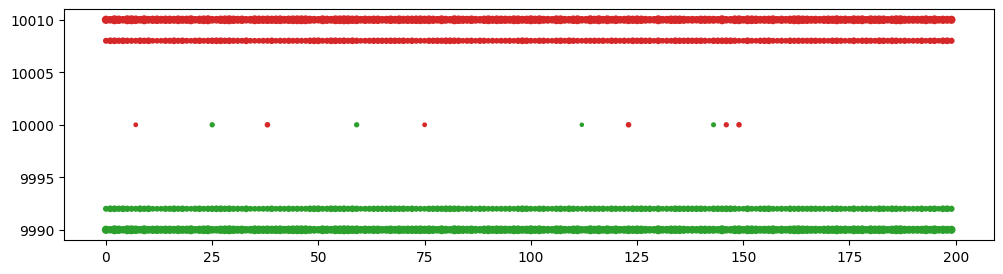

In [10]:
plt.figure(figsize=(12, 3))
plt.scatter(price_resin.iloc[:200]['timestamp']//100, price_resin.iloc[:200]['bid_price_1'], s=price_resin.iloc[:200]['bid_volume_1'], c='tab:green')
plt.scatter(price_resin.iloc[:200]['timestamp']//100, price_resin.iloc[:200]['bid_price_2'], s=price_resin.iloc[:200]['bid_volume_2'], c='tab:green')
plt.scatter(price_resin.iloc[:200]['timestamp']//100, price_resin.iloc[:200]['bid_price_3'], s=price_resin.iloc[:200]['bid_volume_3'], c='tab:green')
plt.scatter(price_resin.iloc[:200]['timestamp']//100, price_resin.iloc[:200]['ask_price_1'], s=price_resin.iloc[:200]['ask_volume_1'], c='tab:red')
plt.scatter(price_resin.iloc[:200]['timestamp']//100, price_resin.iloc[:200]['ask_price_2'], s=price_resin.iloc[:200]['ask_volume_2'], c='tab:red')
plt.scatter(price_resin.iloc[:200]['timestamp']//100, price_resin.iloc[:200]['ask_price_3'], s=price_resin.iloc[:200]['ask_volume_3'], c='tab:red')
plt.show()

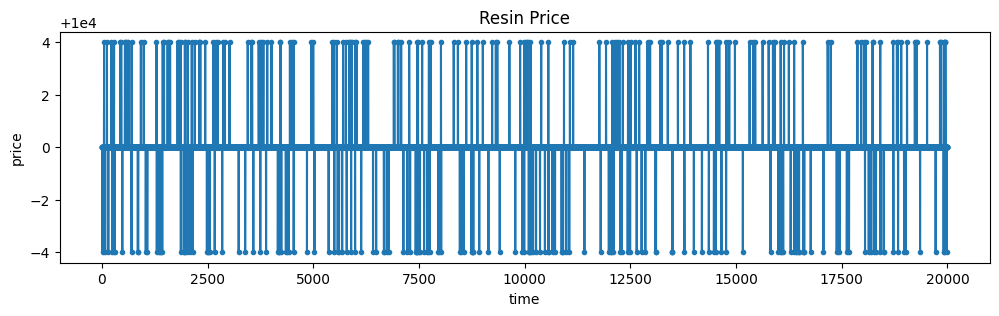

In [11]:
plt.figure(figsize=(12, 3))
plt.plot(price_resin['mid_price'], marker='.')
plt.title('Resin Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

In [12]:
trades_resin.head()

,timestamp,symbol,price,quantity
2,4000,EMERALDS,10008.0,7
4,5200,EMERALDS,9992.0,5
7,10500,EMERALDS,10008.0,5
9,11300,EMERALDS,9992.0,3
16,22800,EMERALDS,10000.0,6


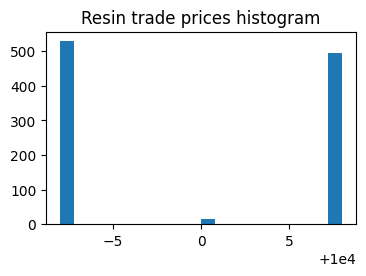

In [13]:
plt.figure(figsize=(4, 2.5))
plt.hist(trades_resin['price'], bins=20, weights=trades_resin['quantity'])
plt.title('Resin trade prices histogram')
plt.show()

# Kelp

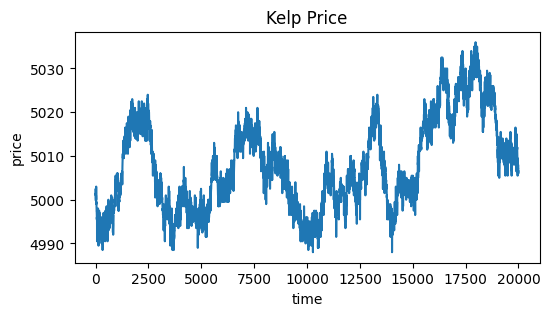

In [14]:
plt.figure(figsize=(6, 3))
plt.plot(price_kelp['mid_price'])
plt.title('Kelp Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

In [15]:
price_kelp.head()

,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price
1,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0
2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5
4,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0
7,300,TOMATOES,4995,5,4993,21,NaN,NaN,5008,5,5009,21,NaN,NaN,5001.5
9,400,TOMATOES,4995,8,4993,20,NaN,NaN,5008,8,5009,20,NaN,NaN,5001.5


In [16]:
trades_kelp.head()

,timestamp,symbol,price,quantity
0,900,TOMATOES,5008.0,2
1,1700,TOMATOES,5006.0,3
3,4100,TOMATOES,5002.0,3
5,6700,TOMATOES,4988.0,5
6,7100,TOMATOES,5000.0,3


## Price prediction - mid price

In [17]:
kelp_mid_prices = price_kelp['mid_price'].to_numpy()

train = kelp_mid_prices[:1000]
test = kelp_mid_prices[1000:]

train_logr = np.log(train[1:] / train[:-1])
test_logr = np.log(test[1:] / test[:-1])

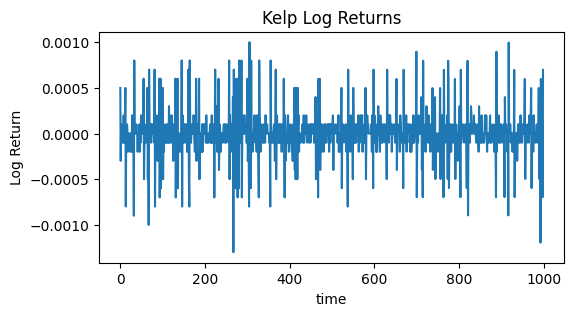

In [18]:
plt.figure(figsize=(6, 3))
plt.plot(train_logr)
plt.title('Kelp Log Returns')
plt.xlabel('time')
plt.ylabel('Log Return')
plt.show()

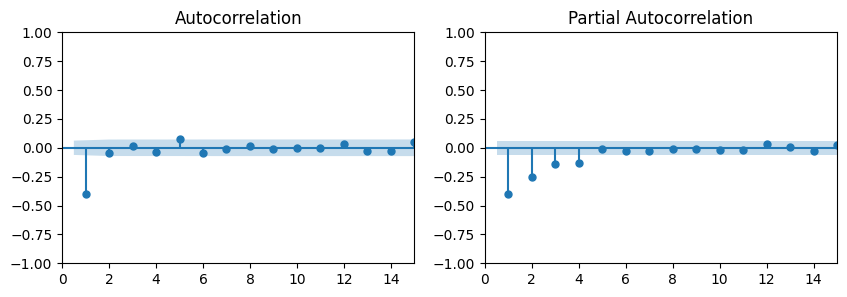

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(train_logr, ax=ax[0], zero=False)
plot_pacf(train_logr, ax=ax[1], zero=False)
ax[0].set_xlim([0, 15])
ax[1].set_xlim([0, 15])
plt.show()

- the PACF is exponentially decaying or sinusoidal;
- there is a significant spike at lag q=1 in the ACF, but none beyond lag q=1.
- -> ARIMA(0,1,1) or MA(1)

### Naive

In [20]:
y = test[1:]
y_pred = test[:-1]
err = y - y_pred
rmse = np.mean(err ** 2) ** 0.5
print(rmse)

1.3484484216702917


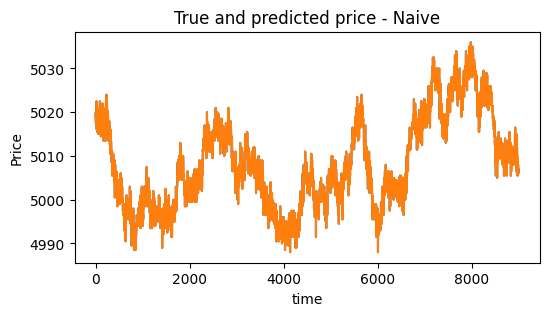

In [21]:
plt.figure(figsize=(6, 3))
plt.plot(y)
plt.plot(y_pred)
plt.title('True and predicted price - Naive')
plt.xlabel('time')
plt.ylabel('Price')
plt.show()

### MA(1)

In [22]:
model = ARIMA(train_logr, order=(0, 0, 1))
result = model.fit()
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(0, 0, 1)   Log Likelihood                6956.972
Date:                Wed, 25 Mar 2026   AIC                         -13907.944
Time:                        19:26:31   BIC                         -13893.224
Sample:                             0   HQIC                        -13902.349
                                - 999                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.663e-06   3.39e-06      0.786      0.432   -3.98e-06     9.3e-06
ma.L1         -0.5425      0.023    -23.158      0.000      -0.588      -0.497
sigma2      5.281e-08   1.34e-09     39.538      0.0

C:\Users\aeali\PycharmProjects\imc-prosperity-4\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [23]:
result.params

array([ 2.66270526e-06, -5.42549689e-01,  5.28074987e-08])

In [24]:
errs = [test_logr[0] - 0]
preds = [0]
for i in range(1, len(test_logr)):
    pred = ma_model(epsilon_prev=errs[i-1], const=result.params[0], theta=result.params[1], sigma2=result.params[2])
    err = test_logr[i] - pred
    preds.append(pred)
    errs.append(err)

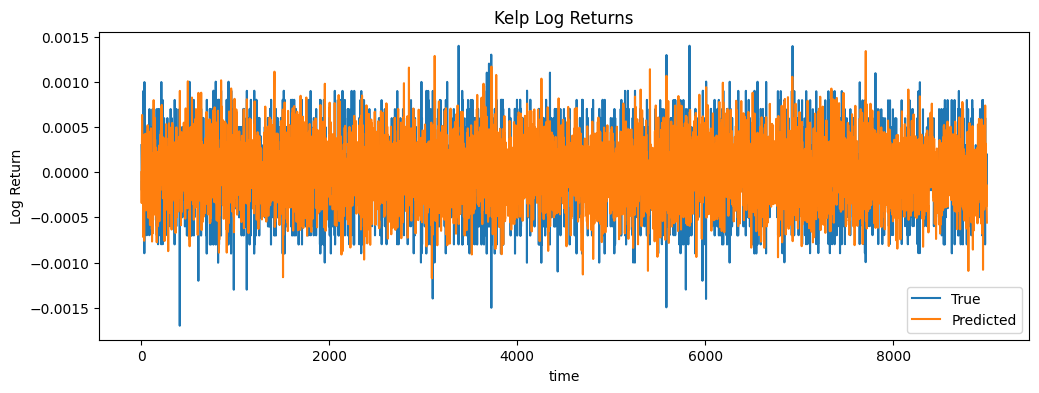

In [25]:
plt.figure(figsize=(12, 4))
plt.plot(test_logr, label='True')
plt.plot(preds, label='Predicted')
plt.title('Kelp Log Returns')
plt.xlabel('time')
plt.ylabel('Log Return')
plt.legend()
plt.show()

In [26]:
len(preds), len(test_logr), len(test)

(8999, 8999, 9000)

In [27]:
pred_price = test[:-1] * np.exp(preds)

In [28]:
err = test[1:] - pred_price
rmse = np.mean(err ** 2) ** 0.5
print(rmse)

1.8072628838631906


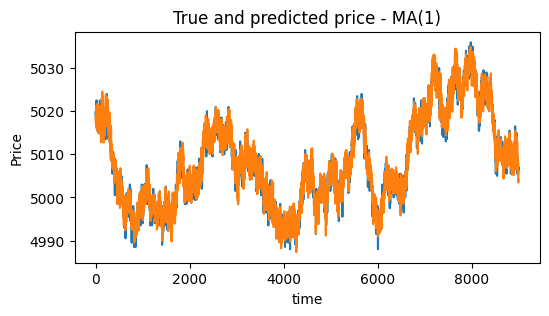

In [29]:
plt.figure(figsize=(6, 3))
plt.plot(test[1:])
plt.plot(pred_price)
plt.title('True and predicted price - MA(1)')
plt.xlabel('time')
plt.ylabel('Price')
plt.show()